In [187]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

from datetime import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal

options={"disp": False} # To not get verbose from minimize function

# Algorithms

## Helper functions for algorithms

First I define some functions that will be used later in all algorithms.

In [132]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [133]:
# NOTE TO DO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

In [134]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    if method == "suffix_averaging":
        i = round((1-p)*n)
        result = np.mean(array[i:], axis=0)
    elif method == "uniform" or method is None:
        result = np.mean(array, axis=0)
    elif method == "last_iterate":
        last_iterate = n - 1
        result = array[last_iterate]
    else:
        raise ValueError("Method must be one of the options")
    return result

In [135]:
def log_loss(betas,data_x,data_y):
    return sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [290]:
def generate_y(n,x, betas, linearly_dependent_on_x = True, all_x = True, independent_method = 1,sinusoidal = False, quadratic = False, seed = 40):
    y = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    if linearly_dependent_on_x and all_x:
        if sinusoidal:
            for t in range(n):
                prob_y1 = (1/2)*np.sin(np.inner(x[t],betas)) + 1/2
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
        elif quadratic:
            for t in range(n):
                prob_y1 = sig(np.inner(x[t]**2,betas))
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
        else:   # following sigmoid function
            for t in range(n):
                prob_y1 = sig(np.inner(x[t],betas))
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
    elif linearly_dependent_on_x:
        x1_x2 = x[:,0:2]
        for t in range(n):
            prob_y1 = sig(np.inner(x1_x2[t],betas[0:2]))
            y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
    elif sinusoidal:
        for t in range(n):
            prob_y1 = np.sin(np.inner(x[t],betas))
            y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
    else:
        if independent_method == 1:
            prob_y1 = rng.uniform(0.1,0.9)
            y = rng.choice([1,-1], size = n, p = [prob_y1, 1-prob_y1])
        if independent_method == 2:
            for t in range(n):
                prob_y1 = sig(np.inner((1/x[t]),betas))
                y[t] = rng.choice([1,-1], size = 1, p = [prob_y1, 1-prob_y1]).item()
        if independent_method == 3:
            # Unbalanced classes
            prob_y1 = 0.8
            y = rng.choice([1,-1], size = n, p = [prob_y1, 1-prob_y1])

    return y

In [137]:
def generate_x(n,d, correlated = True, means = None, sds = None, highly_correlated = True, seed = 40):
    rng = np.random.default_rng(seed) # Random number generator
    if sds is None:
        sds = rng.uniform(0.1,4,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]

    if not correlated:
        cov = np.diag(np.zeros(d))
        x = np.random.multivariate_normal(means, cov, size = n)
    if correlated:
        diagonal = rng.uniform(9,10,d)
        cov = np.diag(diagonal)
        x = np.random.multivariate_normal(means, cov, size = n)
        if highly_correlated and d == 3:
            x1 = generate_x(n,1)
            x2 = x1 + rng.normal(2,1)
            x3 = x1 + x2
            x = np.concatenate((x1,x2,x3), axis = 1)

    return x


## Online Gradient Descent

In [138]:
def online_gd(n, d, data_y, data_x, B, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.now()

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0


    # Store endtime
    end_time = datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [139]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [140]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result
    def debug(self):
        print(self.etas_gradients)

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : sum(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b"):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                beta_tilde = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # Project beta onto set
            #betas[t] = project_onto_l2_ball(beta_tilde,B)
            #betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

In [141]:
x = generate_x(15,20)
betas = np.random.uniform(0.1,5,20)
y = generate_y(15,x,betas = betas)

x_train = x[:10]
y_train = y[:10]
x_test = x[10:]
y_test = y[10:]

### AIOLI convergence check

In [142]:
aioli_model = AIOLI()
aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b")
aioli_results

{'runtime': 0.190585,
 'Total_Loss': np.float64(3.8222498426749635e-86),
 'Online_Loss': np.float64(6.892092358153239),
 'Batch_estimate': array([  1.17515346,  37.1793345 ,  -4.98490008,  11.1581943 ,
         29.92568563, -11.32907714,  -3.00298285, -13.77657454,
         33.01307914,  12.01164492,  11.88186851,  14.56876425,
          2.02149073,  19.68519005,  -8.12622686,  -2.24052675,
          7.66935009, -12.06730195,   2.64296756,  32.4882554 ]),
 'All_Betas': array([[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ],
        [ -3.81369598,  18.9969644 ,  -8.645807  ,  -3.86337292,
           9.64052457,  -3.03923618,  -3.16206715,  -5.17758659,
          29.01140323,   1.00044138,  -7.35777748,   7.39421026,
      

In [143]:
minimization_methods = ["l-bfgs-b",'bfgs',"CG"]

for method in minimization_methods:
    aioli_model = AIOLI()
    aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = method)
    print(f"Method: {method}")
    print(f"convergence: {aioli_results["convergence"]}")
    print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
    print(f"Online loss: {aioli_results["Online_Loss"]}")


Method: l-bfgs-b
convergence: 9
minimizer_gradient: 0.01829027043436332
Online loss: 6.892092358153239
Method: bfgs
convergence: 2
minimizer_gradient: 0.0007256761443679954
Online loss: 6.893045195309687
Method: CG
convergence: 2
minimizer_gradient: 0.002447985175228559
Online loss: 6.893003735824271


In [144]:
aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

{'runtime': 1.283958, 'loss': np.float64(3.4414112326586976)}

## Ada Grad

In [145]:
# OJO STILL HAVE TO CODE THIS. the code is just OGD.
def online_AdaGrad(n, d, data_y, data_x, B, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.now()

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        #y_hat = sig(np.inner(betas[t],xt)) commented out because its never used so there's no need to calculate it

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0


    # Store endtime
    end_time = datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


## Logistic Regression

In [304]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.now()

    logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)

    try:
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [191]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [368]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000, random_state=1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LG was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [147]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

# Functions for simulations

## Data class for specifying simulation configuration

In [296]:
@dataclass
class SimulationConfig:
    # Default is well specified
    runs: int = 5
    n: int = 200
    d: int = 3
    betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    B: int = 40
    X: int = 10
    test_ratio: float = 0.3
    minimize_method: str = "l-bfgs-b"
    sinusoidal: bool = False
    quadratic: bool = False

## Function to run simulations and get results

In [305]:
def run_simulation(cfg: SimulationConfig):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    betas = cfg.betas
    x_means = cfg.x_means
    B = cfg.B
    X = cfg.X
    test_ratio = cfg.test_ratio
    minimize_method = cfg.minimize_method
    sinusoidal_bool = cfg.sinusoidal
    quadratic_bool = cfg.quadratic

    results_all = []
    test_set_results = []

    for i in range(runs):

        test_size = round(n * test_ratio)
        train_size = n - test_size

        x = generate_x(n, d, means = x_means, seed = 40 + i)
        y = generate_y(n, x, betas, seed = 40 + i, sinusoidal = sinusoidal_bool, quadratic = quadratic_bool)

        # Split train/test
        x_train, y_train, x_test, y_test = x[:train_size], y[:train_size], x[train_size:], y[train_size:]

        # Run algorithms
        ogd = online_gd(n=train_size, d=d, data_y=y_train, data_x=x_train, B=B)
        aioli_model = AIOLI()
        ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=X, B=B, minimize_method = minimize_method)
        classic_lg = classic_logistic_regression(data_x=x_train, data_y=y_train)
        ridge_lg = ridge_logistic_regression(data_x=x_train, data_y=y_train)

        # OTB estimates
        OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
        OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
        OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")

        # Training losses
        loss_OGD_Suffix = log_loss(OGD_OTB_Suffix, x_train, y_train)
        loss_OGD_lastit = log_loss(OGD_OTB_lastit, x_train, y_train)

        # TRAINING RESULTS

        algorithms_train = {
            "OGD_uniform": {
                "runtime": ogd["runtime"],
                "loss (trainset)": ogd["Total_Loss"],
                "online_loss": ogd["Online_Loss"],
                "betas": ogd["Batch_estimate"]
            },
            "OGD_Suffix": {
                "loss (trainset)": loss_OGD_Suffix,
                "betas": OGD_OTB_Suffix
            },
            "OGD_Last_iterate": {
                "loss (trainset)": loss_OGD_lastit,
                "betas": OGD_OTB_lastit
            },
            "AIOLI_uniform": {
                "runtime": ai["runtime"],
                "loss (trainset)": ai["Total_Loss"],
                "online_loss": ai["Online_Loss"],
                "betas": ai["Batch_estimate"],
                "convergence": ai["convergence"],
                "minimizer_gradient": ai["minimizer_gradient"]
            },
            "Classical_LG": {
                "runtime": classic_lg["runtime"],
                "loss (trainset)": classic_lg["Total_Loss"],
                "betas": classic_lg["Batch_estimate"]
            },
            "Ridge_LG": {
                "runtime": ridge_lg["runtime"],
                "loss (trainset)": ridge_lg["Total_Loss"],
                "betas": ridge_lg["Batch_estimate"]
            }
        }

        for name, metrics in algorithms_train.items():
            results_all.append({"algorithm": name, **metrics})

        # TEST RESULTS

        loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
        loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
        loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

        loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
        loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

        loss_LG_test = log_loss(classic_lg["Batch_estimate"], x_test, y_test)
        loss_LG_Ridge_test = log_loss(ridge_lg["Batch_estimate"],   x_test, y_test)

        algorithms_test = {
            "OGD_uniform": {"loss (testset)": loss_OGD_uniform_test},
            "OGD_Suffix":  {"loss (testset)": loss_OGD_Suffix_test},
            "OGD_Last_iterate": {"loss (testset)": loss_OGD_lastit_test},
            "AIOLI_uniform": {"loss (testset)": loss_AIOLI_uniform_test},
            "AIOLI_Suffix":  {"loss (testset)": loss_AIOLI_Suffix_test},
            "AIOLI_lastit":  {"loss (testset)": loss_AIOLI_lastit_test},
            "Classical_LG":  {"loss (testset)": loss_LG_test},
            "Ridge_LG":      {"loss (testset)": loss_LG_Ridge_test}
        }

        for name, metrics in algorithms_test.items():
            test_set_results.append({"algorithm": name, **metrics})
        print(f"Run {i} finished")

    return {
        "final_results": pd.DataFrame(results_all),
        "test_results": pd.DataFrame(test_set_results)
    }


## Function for printing results

In [150]:
def print_results(results):
    summary_train = results["final_results"].groupby("algorithm")[["runtime", "loss (trainset)", "online_loss", "betas"]].mean()
    summary_train["betas"] = summary_train["betas"].apply(lambda array: np.round(array, 3))
    summary_test = results["test_results"].groupby("algorithm")[["loss (testset)"]].mean()
    display(summary_train)
    display(summary_test)

# Experiments

## Balanced

### X means and betas for balanced data $P(Y=1) = 0.5)$

In [380]:
# Balanced
bs_balanced = [2,0.1,-4.2]
xs_balanced = [2,2,1]
print(np.inner(bs_balanced,xs_balanced))
print(sig(np.inner(bs_balanced,_balanced)))
print((1/2)*np.sin(np.inner(xs_balanced,bs_balanced)) + 1/2)

0.0
0.5
0.5


In [381]:
# Balanced High dimensional (25 variables)
bs_hd_balanced = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_balanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_balanced), len(xs_hd_balanced))
print(np.inner(bs_hd_balanced,xs_hd_balanced))
print(sig(np.inner(bs_hd_balanced,xs_hd_balanced)))
print((1/2)*np.sin(np.inner(xs_hd_balanced,bs_hd_balanced)) + 1/2)

25 25
-0.02000000000000135
0.49500016665999996
0.4900006666533328


### Experiments

In [307]:
well_specified = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.276021,70.860980,11.797276,"[12.091, -45.406, -33.315]"
Classical_LG,0.002824,3.086892,NaN,"[-2.21, -16.636, -18.845]"
OGD_Last_iterate,NaN,6.167409,NaN,"[-0.346, -0.66, -1.006]"
OGD_Suffix,NaN,6.389747,NaN,"[-0.362, -0.629, -0.991]"
OGD_uniform,0.001945,6.726297,7.572050,"[-0.355, -0.576, -0.932]"
Ridge_LG,0.002053,4.887381,NaN,"[-0.227, -1.023, -1.25]"


,loss (testset)
algorithm,
AIOLI_Suffix,2.084134
AIOLI_lastit,2.935248
AIOLI_uniform,1.891653
Classical_LG,2.845599
OGD_Last_iterate,2.471271
OGD_Suffix,2.519061
OGD_uniform,2.641186
Ridge_LG,2.189906


In [367]:
high_dimensional = SimulationConfig(
    runs = 10,
    n = 20,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.590939,185.992448,9.688919,"[4.523, 9.134, -25.913, 13.062, 5.348, -3.708,..."
Classical_LG,0.004204,0.000340,NaN,"[0.265, 0.206, -0.795, 0.218, 0.072, -0.1, -0...."
OGD_Last_iterate,NaN,8.970260,NaN,"[-0.01, 0.07, -0.164, 0.058, 0.043, 0.037, -0...."
OGD_Suffix,NaN,6.354196,NaN,"[-0.02, 0.07, -0.145, 0.074, 0.046, -0.003, -0..."
OGD_uniform,0.000323,13.492307,31.632223,"[-0.017, 0.082, -0.101, 0.087, 0.037, -0.043, ..."
Ridge_LG,0.004961,0.259619,NaN,"[0.085, 0.072, -0.256, 0.08, 0.011, -0.038, -0..."


,loss (testset)
algorithm,
AIOLI_Suffix,4.141617
AIOLI_lastit,4.132046
AIOLI_uniform,4.147445
Classical_LG,8.743626
OGD_Last_iterate,10.752842
OGD_Suffix,7.846324
OGD_uniform,8.079035
Ridge_LG,4.312147


In [370]:
high_dimensionality = SimulationConfig(
    runs = 5,
    n = 50,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,5.269485,428.521244,23.220782,"[19.683, 19.858, -58.35, 41.818, 21.23, 2.341,..."
Classical_LG,0.003594,0.000899,NaN,"[0.74, 0.336, -1.804, 0.806, 0.439, 0.28, -0.5..."
OGD_Last_iterate,NaN,12.005790,NaN,"[0.069, 0.16, -0.227, 0.095, 0.01, 0.004, -0.0..."
OGD_Suffix,NaN,10.973473,NaN,"[0.046, 0.167, -0.217, 0.107, -0.003, -0.01, -..."
OGD_uniform,0.001134,21.154617,52.004354,"[0.033, 0.152, -0.176, 0.062, -0.02, -0.0, -0...."
Ridge_LG,0.003761,0.611133,NaN,"[0.247, 0.115, -0.59, 0.279, 0.138, 0.062, -0...."


,loss (testset)
algorithm,
AIOLI_Suffix,9.640656
AIOLI_lastit,8.866588
AIOLI_uniform,9.985430
Classical_LG,25.727275
OGD_Last_iterate,13.620216
OGD_Suffix,12.495247
OGD_uniform,14.718178
Ridge_LG,10.682186


In [294]:
sinusoidal = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    sinusoidal = True
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.249987,716.552607,207.227827,"[3.667, -2.438, 1.228]"
Classical_LG,0.002102,46.810908,NaN,"[0.046, -0.034, 0.011]"
OGD_Last_iterate,NaN,50.219538,NaN,"[0.059, -0.05, 0.009]"
OGD_Suffix,NaN,48.491382,NaN,"[0.058, -0.049, 0.009]"
OGD_uniform,0.001033,49.764183,65.373792,"[0.074, -0.044, 0.03]"
Ridge_LG,0.002229,46.812894,NaN,"[0.042, -0.03, 0.012]"


,loss (testset)
algorithm,
AIOLI_Suffix,34.200535
AIOLI_lastit,33.742330
AIOLI_uniform,51.512401
Classical_LG,21.674646
OGD_Last_iterate,21.956313
OGD_Suffix,21.459579
OGD_uniform,22.693900
Ridge_LG,21.621670


In [298]:
quadratic = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    quadratic = True
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.237085,622.029744,541.332026,"[76.315, -73.696, 2.618]"
Classical_LG,0.002643,17.904394,NaN,"[1.434, -1.389, 0.046]"
OGD_Last_iterate,NaN,26.780473,NaN,"[0.549, -0.484, 0.066]"
OGD_Suffix,NaN,26.891264,NaN,"[0.528, -0.447, 0.082]"
OGD_uniform,0.000935,29.057803,38.602424,"[0.476, -0.374, 0.102]"
Ridge_LG,0.002381,18.204598,NaN,"[1.216, -1.169, 0.048]"


,loss (testset)
algorithm,
AIOLI_Suffix,140.537922
AIOLI_lastit,118.648342
AIOLI_uniform,224.814796
Classical_LG,8.380748
OGD_Last_iterate,12.844982
OGD_Suffix,12.433187
OGD_uniform,13.822012
Ridge_LG,8.329988


## Unbalanced

### X means and betas for unbalanced data $P(Y=1)$ -> 1 or 0)


In [378]:

# Unbalanced
bs_unbalanced = [1.5,0.1,-4.2]
xs_unbalanced = [2,2,1]
print(np.inner(bs_unbalanced,xs_unbalanced))
print(sig(np.inner(bs_unbalanced,xs_unbalanced)))
print((1/2)*np.sin(np.inner(xs_unbalanced,bs_unbalanced)) + 1/2)

# High dimensional

-1.0
0.2689414213699951
0.07926450759605175


In [379]:
# Unbalanced High dimensional (25 variables)
bs_hd_unbalanced = [2,1.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_unbalanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_unbalanced), len(xs_hd_unbalanced))
print(np.inner(bs_hd_unbalanced,xs_hd_unbalanced))
print(sig(np.inner(bs_hd_unbalanced,xs_hd_unbalanced)))
print((1/2)*np.sin(np.inner(xs_hd_unbalanced,bs_hd_unbalanced)) + 1/2)

25 25
2.08
0.8889440332885924
0.9365664897537582


### Experiments

In [303]:
well_specified_unbalanced = SimulationConfig(
    betas= bs_unbalanced,
    x_means= xs_unbalanced
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.441703,69.321624,18.932169,"[-0.023, -32.16, -32.183]"
Classical_LG,0.001954,9.171569,NaN,"[-0.303, -2.301, -2.604]"
OGD_Last_iterate,NaN,12.467343,NaN,"[-0.397, -0.739, -1.136]"
OGD_Suffix,NaN,12.783353,NaN,"[-0.376, -0.709, -1.086]"
OGD_uniform,0.002923,13.550260,14.804267,"[-0.373, -0.632, -1.005]"
Ridge_LG,0.001594,10.286873,NaN,"[-0.292, -1.241, -1.533]"


,loss (testset)
algorithm,
AIOLI_Suffix,3.111332
AIOLI_lastit,4.316231
AIOLI_uniform,3.232236
Classical_LG,3.913688
OGD_Last_iterate,4.336224
OGD_Suffix,4.518120
OGD_uniform,4.868355
Ridge_LG,3.670973


In [376]:
high_dimensional_unbalanced = SimulationConfig(
    runs = 10,
    n = 20,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished
Run 5 finished
Run 6 finished
Run 7 finished
Run 8 finished
Run 9 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.677154,348.658470,9.687631,"[9.996, 14.281, -5.159, 13.001, -1.526, -8.405..."
Classical_LG,0.005302,0.000381,NaN,"[0.327, 0.444, -0.455, 0.32, -0.026, -0.145, -..."
OGD_Last_iterate,NaN,11.666906,NaN,"[0.073, 0.106, -0.094, 0.086, 0.014, -0.042, -..."
OGD_Suffix,NaN,8.877079,NaN,"[0.07, 0.107, -0.068, 0.101, 0.01, -0.085, -0...."
OGD_uniform,0.000204,16.309833,34.721179,"[0.038, 0.091, -0.04, 0.098, 0.022, -0.103, -0..."
Ridge_LG,0.005895,0.285435,NaN,"[0.108, 0.161, -0.152, 0.097, 0.007, -0.061, -..."


,loss (testset)
algorithm,
AIOLI_Suffix,4.146633
AIOLI_lastit,4.142395
AIOLI_uniform,4.150299
Classical_LG,14.498943
OGD_Last_iterate,8.330983
OGD_Suffix,4.805917
OGD_uniform,7.766160
Ridge_LG,5.748445


In [377]:
high_dimensionality_unbalanced = SimulationConfig(
    runs = 5,
    n = 50,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


Run 0 finished
Run 1 finished
Run 2 finished
Run 3 finished
Run 4 finished


,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,4.463423,1363.828765,23.824473,"[12.31, 47.112, -59.792, 11.897, 9.965, 3.822,..."
Classical_LG,0.004309,0.001496,NaN,"[0.792, 1.515, -2.526, 0.386, 1.324, 0.075, -0..."
OGD_Last_iterate,NaN,22.769450,NaN,"[0.059, 0.116, -0.269, 0.117, 0.06, -0.053, 0...."
OGD_Suffix,NaN,18.355586,NaN,"[0.058, 0.107, -0.243, 0.113, 0.043, -0.028, -..."
OGD_uniform,0.000510,24.065697,58.455732,"[0.051, 0.065, -0.221, 0.091, 0.031, 0.007, -0..."
Ridge_LG,0.006224,1.173263,NaN,"[0.23, 0.403, -0.653, 0.081, 0.349, 0.009, -0...."


,loss (testset)
algorithm,
AIOLI_Suffix,9.551037
AIOLI_lastit,8.962435
AIOLI_uniform,9.940765
Classical_LG,37.082052
OGD_Last_iterate,13.941665
OGD_Suffix,12.286553
OGD_uniform,15.065028
Ridge_LG,11.528738


In [301]:
sinusoidal_unbalanced = SimulationConfig(
    runs = 10,
    n = 100,
    d = 3,
    betas= bs_unbalanced,
    x_means= xs_unbalanced,
    sinusoidal = True
)

sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
print_results(sinusoidal_unbalanced_result)

,runtime,loss (trainset),online_loss,betas
algorithm,,,,
AIOLI_uniform,0.291651,1184.125837,156.104564,"[-0.114, 1.235, 1.12]"
Classical_LG,0.002160,47.030414,NaN,"[-0.022, 0.026, 0.004]"
OGD_Last_iterate,NaN,50.185807,NaN,"[0.039, -0.048, -0.008]"
OGD_Suffix,NaN,49.117018,NaN,"[0.053, -0.061, -0.009]"
OGD_uniform,0.001034,51.422473,63.517288,"[0.065, -0.065, -0.0]"
Ridge_LG,0.002173,47.031356,NaN,"[-0.021, 0.025, 0.004]"


,loss (testset)
algorithm,
AIOLI_Suffix,44.650102
AIOLI_lastit,90.408683
AIOLI_uniform,46.509297
Classical_LG,21.674099
OGD_Last_iterate,21.765108
OGD_Suffix,23.230640
OGD_uniform,25.620717
Ridge_LG,21.658530


## Graphing different data generating functions

<Axes: >

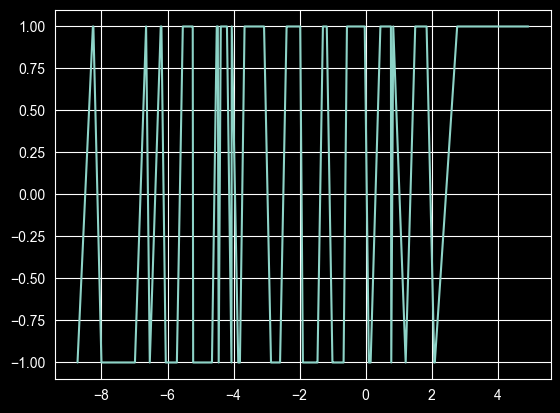

In [291]:
x_s = generate_x(100,d = 3, means = [2,2,1])
betas_s = [2,0.1,-4.2]
y_s = generate_y(n = 100,x = x_s, betas = betas_s, sinusoidal=True)

sns.lineplot(x = x_s[:,0].flatten(), y = y_s)

<Axes: >

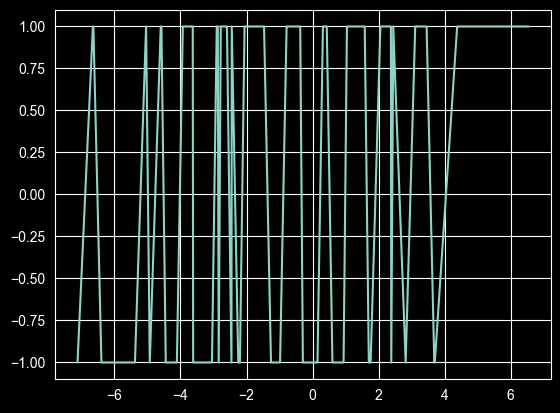

In [292]:

sns.lineplot(x = x_s[:,1].flatten(), y = y_s)

<Axes: >

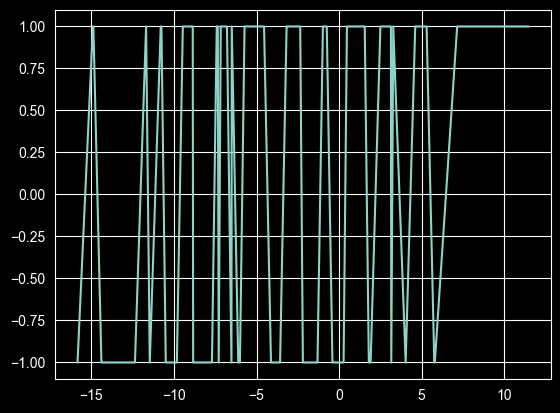

In [293]:
sns.lineplot(x = x_s[:,2].flatten(), y = y_s)

array([ -4.09189969,   6.14177765,   2.68374127,  -3.83591074,
        -2.51844859,   2.69983766,  -0.68132609,   1.38467277,
        -2.91818096,   2.44592957,   1.09513341,   7.20836307,
        -0.6877384 ,   1.76555054,   5.60544694,   6.4841433 ,
        -0.83599207,   6.14851522,  -3.67310168,   7.28415663,
         4.58520751,   4.52420731,  -2.42036591,  -0.75142411,
        -9.2596181 ,   6.63743087,  -2.94565237,   4.51613383,
        -2.26816365,   1.35134803,  -3.5102675 ,  -0.2099203 ,
         1.62093357,   2.60935658,  -5.31483557,   4.84101945,
        -1.21762948,   4.42709363,   4.10221266,   2.03882641,
        -1.83641313,   0.93455672,   0.12123795,   6.09490126,
        -4.79560865,   3.61558495,   1.78583285,   1.18094713,
        -1.99606021,   3.66808698,   1.62489356,   2.10066793,
        -3.95750848,  -2.68082723,   0.82265772,   8.24115176,
        -5.70655338,   6.55950967,  -0.11144638,   2.19140518,
        -4.45048111,   4.41020578,  -1.73515592,   5.12

In [272]:
x_s[:,0].flatten()

array([ 9.55354465e-01, -5.46724933e+00, -4.49376537e+00,  1.09268541e+00,
       -2.96085088e+00, -5.79393842e-01, -1.04337160e+01, -2.41697914e+00,
       -2.90780079e+00,  4.65640601e+00, -1.39667979e+00,  3.34063923e+00,
        2.50556073e-01,  1.01633913e+00, -1.12631846e+00, -3.98862663e+00,
       -2.74669520e+00, -1.89627562e+00, -3.87624867e-01, -9.64012790e-01,
       -2.90737836e-01, -9.09433414e+00, -5.83443645e+00, -2.75960005e+00,
       -7.80380764e-01, -5.16717406e+00, -5.73461470e+00, -6.56447414e-01,
        4.47747811e-01, -4.25582387e+00, -2.28827022e+00, -9.02977195e-02,
        1.49066629e+00,  2.38816388e-03,  4.23357615e+00, -4.30412473e+00,
       -1.96248431e+00,  3.39607465e+00, -6.26762718e-01,  1.04874330e+00,
        1.10215764e+00, -2.24272322e+00, -3.71584852e+00, -6.10257355e+00,
       -2.25969218e+00, -4.10957988e+00,  1.96152142e+00, -3.62564242e+00,
        3.21569664e+00,  1.91358807e+00,  2.05379312e+00, -5.48157704e+00,
       -1.78670581e+00, -

In [186]:

# Data
# y = np.array([1,1,1,1,1,1,1,1,1])
# X = np.array([
#     [1,3,2],
#     [2,3,6],
#     [3,1,4],
#     [1,0,2],
#     [0,1,1],
#     [2,2,2],
#     [3,3,1],
#     [1,1,1],
#     [2,3,1]
# ])
#
# # Negative log-likelihood (sigmoid applied inline)
# def neg_loglik(beta):
#     z = X @ beta
#     p = 1 / (1 + np.exp(-z))          # sigmoid inline
#     #p = np.clip(p, 1e-12, 1 - 1e-12)  # numerical stability
#     return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
#
# # Initial guess
# beta0 = np.zeros(X.shape[1])
#
# # Optimize
# res = minimize(neg_loglik, beta0, method="BFGS")
#
# print("Optimal beta:", res.x)
# print("Converged:", res.success)
# print("Final negative log-likelihood:", res.fun)


Optimal beta: [-193.37002762  272.6264169   550.79426278]
Converged: False
Final negative log-likelihood: nan


C:\Users\marie\AppData\Local\Temp\ipykernel_9620\3778556553.py:20: RuntimeWarning: divide by zero encountered in log
  return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
C:\Users\marie\AppData\Local\Temp\ipykernel_9620\3778556553.py:20: RuntimeWarning: invalid value encountered in multiply
  return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
C:\Users\marie\AppData\Local\Temp\ipykernel_9620\3778556553.py:20: RuntimeWarning: divide by zero encountered in log
  return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
C:\Users\marie\AppData\Local\Temp\ipykernel_9620\3778556553.py:20: RuntimeWarning: invalid value encountered in multiply
  return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
C:\Users\marie\AppData\Local\Temp\ipykernel_9620\3778556553.py:20: RuntimeWarning: divide by zero encountered in log
  return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
C:\Users\marie\AppData\Local\Temp\ipykernel_9620\3778556553.py:20: RuntimeWarning: invalid value encountered in multi

### Check AIOLI convergence

In [ ]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["convergence"].mean() * 100 / n).item(),2)

In [ ]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["minimizer_gradient"].mean() * 100 / n).item(),2)

# Ignore from here on, it's simply code to test some functions/debugging

## Tests

In [ ]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [ ]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [ ]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [ ]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [ ]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [ ]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [ ]:
# np.log(1000)

## OTB conversion proof tests

In [ ]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))